# 🖼️ 멀티모달 비전-언어 모델(VLM) 인스트럭트 튜닝 실습 (강의용)

이 노트북은 **(Vision Encoder + Language Model)** 을 결합해 아주 작은 형태의 VLM을 만들고,  
이미지-질문-답변(instruction) 데이터로 **instruction tuning** 하는 과정을 단계별로 실습합니다.

---

## 학습 목표

1. 멀티모달 학습에서 **데이터 포맷(이미지 + 텍스트 대화)** 이 어떻게 구성되는지 이해한다.
2. Vision Encoder(ResNet18)와 Text Decoder(GPT-2)를 연결하는 가장 단순한 방식인  
   **“특수 토큰(`<img>`) 위치의 임베딩을 이미지 특징으로 치환”** 방법을 구현/이해한다.
3. 3단계 학습 파이프라인을 구성한다.
   - (A) Vision Encoder: CIFAR-10 분류로 워밍업
   - (B) Language Model: ELI5 텍스트로 LM 파인튜닝
   - (C) Vision-Language: 이미지+대화 데이터로 instruction tuning
4. **perplexity** 기반으로 간단한 평가를 수행한다.

---

> ⚠️ 주의: 본 실습은 **강의/이해용 toy 구현**입니다. 실제 LLaVA/InternVL류 모델은  
> 이미지 패치를 여러 토큰으로 펼치고(예: 256~576 tokens), cross-attention 또는 Q-Former 등 더 정교한 결합을 사용합니다.


## 0. 환경 준비

아래 셀은 Colab/로컬 환경에서 필요한 패키지를 설치하고(필요 시), GPU/Seed 등을 설정합니다.

- GPU가 있다면 학습이 훨씬 빠릅니다.
- 인터넷이 막혀있다면 Hugging Face 데이터셋(CIFAR/ELI5) 다운로드가 안 될 수 있습니다.


In [1]:
# 패키지 준비 (Colab/로컬 공통)
# - 이미 설치되어 있다면 설치 단계는 건너뜁니다.
# - 설치가 필요한 경우: 아래 셀을 한 번 실행한 뒤 런타임 재시작이 필요할 수 있습니다.

try:
    import transformers, datasets, tqdm, PIL, matplotlib  # noqa: F401
    print("✅ Required packages are already installed.")
except Exception as e:
    print("Installing missing packages... (this may take a few minutes)")
    %pip -q install transformers datasets tqdm pillow matplotlib

import os, json, zipfile, random
import numpy as np
from dataclasses import dataclass
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from transformers import GPT2Tokenizer, GPT2LMHeadModel
from datasets import load_dataset
from PIL import Image
from tqdm.auto import tqdm

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())


/opt/conda/envs/sam/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Required packages are already installed.
torch: 2.10.0+cu128
cuda available: True


## 1. 실습 데이터 준비 (instruct_tuning.zip)

이번 실습의 멀티모달 instruction 데이터는 다음 형태입니다.

- `instruct.json`: 샘플 목록  
  - `image`: 이미지 파일명  
  - `conversation`: `[{'from': 'human', 'value': 질문}, {'from': 'gpt', 'value': 답변}]`
- `images/`: 실제 이미지 파일들

아래 셀에서 zip을 풀고, 데이터 구조를 확인합니다.


In [2]:
ZIP_PATH = Path("instruct_tuning.zip")  # 노트북과 같은 폴더에 있다고 가정
OUT_DIR = Path("./instruct_tuning")

if ZIP_PATH.exists() and not OUT_DIR.exists():
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(OUT_DIR)
    print("✅ Extracted to:", OUT_DIR.resolve())
else:
    print("ZIP_PATH exists:", ZIP_PATH.exists(), "| OUT_DIR exists:", OUT_DIR.exists())

JSON_PATH = OUT_DIR / "instruct.json"
IMG_DIR = OUT_DIR / "images"

print("JSON_PATH:", JSON_PATH, "exists:", JSON_PATH.exists())
print("IMG_DIR:", IMG_DIR, "num images:", len(list(IMG_DIR.glob("*.jpg"))))


ZIP_PATH exists: True | OUT_DIR exists: True
JSON_PATH: instruct_tuning/instruct.json exists: True
IMG_DIR: instruct_tuning/images num images: 1020


In [3]:
# 데이터 포맷 살펴보기
with open(JSON_PATH, "r") as f:
    samples = json.load(f)

print("num samples:", len(samples))
print("keys:", samples[0].keys())
print("example:", samples[0]["image"])
print("conversation[0]:", samples[0]["conversation"][0])
print("conversation[1]:", samples[0]["conversation"][1])


num samples: 1020
keys: dict_keys(['id', 'image', 'conversation'])
example: 000000173089.jpg
conversation[0]: {'from': 'human', 'value': 'How many people are present in the image?'}
conversation[1]: {'from': 'gpt', 'value': 'There are two people present in the image.'}


### (선택) 샘플 이미지 시각화

instruction 데이터가 실제로 어떤 이미지인지 확인합니다.


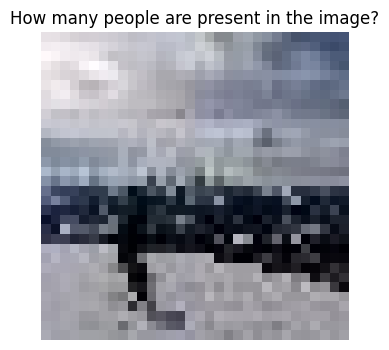

Q: How many people are present in the image?
A: There are two people present in the image.


In [4]:
import matplotlib.pyplot as plt

idx = 0
img_path = IMG_DIR / samples[idx]["image"]
img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.title(samples[idx]["conversation"][0]["value"][:60])
plt.show()

print("Q:", samples[idx]["conversation"][0]["value"])
print("A:", samples[idx]["conversation"][1]["value"])


## 2. 설정(Config)과 Seed 고정

실습 시간/자원에 맞게 **FAST_RUN** 모드로 빠르게 돌릴 수 있도록 설정을 분리합니다.

- `FAST_RUN=True`: 데이터/스텝을 줄여서 빠르게 확인(강의 중 데모용)
- `FAST_RUN=False`: 좀 더 제대로 학습(과제/개인 실습용)


In [5]:
@dataclass
class Config:
    seed: int = 0
    fast_run: bool = True

    # batch sizes
    cifar_batch_size: int = 128
    lm_batch_size: int = 32
    vl_batch_size: int = 16

    # lengths
    max_length: int = 128         # LM block size
    vlm_max_length: int = 32      # VLM sequence length(고정)

    # training epochs
    vision_epochs: int = 1
    lm_epochs: int = 1
    vlm_epochs: int = 1

    # learning rates
    vision_lr: float = 1e-3
    lm_lr: float = 1e-5
    vlm_lr: float = 1e-5

    # fast-run limits (None이면 full)
    cifar_max_batches: int | None = 50
    lm_max_batches: int | None = 80
    vlm_max_batches: int | None = 80

    # tokens
    img_token: str = "<img>"
    hidden_size: int = 768

cfg = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| fast_run:", cfg.fast_run)

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(cfg.seed)


device: cuda | fast_run: True


## 3. Tokenizer 설계: `<img>` 특수 토큰 추가

이번 toy VLM은 텍스트 시퀀스 안에 `<img>` 라는 특수 토큰을 **1개 삽입**하고,  
그 위치의 토큰 임베딩을 **이미지 특징(projected feature)** 으로 바꿔치기합니다.

- GPT-2 기본 vocab size: 50257
- `<img>` 추가 후 vocab size: 50258
- 평가/저장 시에는 `logits[..., :-1]` 로 `<img>` 토큰 차원을 떼어내어 **50257 차원으로 맞춥니다**  
  (제공된 평가 코드와 호환)

> 왜 `<img>` 차원을 떼나요?  
> 평가 코드/스펙이 50257 vocab 기준으로 작성되어 있기 때문입니다. fileciteturn0file2


In [6]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # GPT-2는 원래 pad가 없음 -> eos로 대체
tokenizer.add_tokens(cfg.img_token, special_tokens=True)

print("vocab size:", len(tokenizer))
print("img token id:", tokenizer.convert_tokens_to_ids(cfg.img_token))
print("pad token id:", tokenizer.pad_token_id, "| eos token id:", tokenizer.eos_token_id)


vocab size: 50258
img token id: 50257
pad token id: 50256 | eos token id: 50256


### ✅ 채점/호환성 메모 (중요)

- 제공된 평가 코드(`test_vlm.py`)는 **질문 텍스트에 `<img>` 토큰이 들어가지 않는** 형태의 전처리를 사용합니다. fileciteturn0file2  
- 따라서 **`test_vlm.py`를 수정하지 않고 그대로 사용**하려면, 아래 `LLaVADataset` 생성 시 `insert_img_token=False`로 맞춰야 합니다.
- 반대로, 강의에서 **“high-level 멀티모달 결합(이미지 특징 주입)”** 효과를 명확히 보여주려면  
  `insert_img_token=True`(기본값)를 사용하고, 이 노트북 안의 perplexity 평가 함수를 쓰는 것을 추천합니다.

> 강의에서는 `insert_img_token=True`로 진행하고, 필요하면 마지막에 호환 모드도 함께 보여주는 구성을 추천합니다.


## 4. 데이터로더 구성

### 4.1 CIFAR-10 (Vision Encoder 워밍업)
Vision Encoder를 단순히 pretrained feature extractor로만 쓰면 도메인에 따라 불안정할 수 있습니다.  
그래서 **CIFAR-10 분류**로 1 epoch 정도 워밍업/미세조정해봅니다.

### 4.2 ELI5 (Language Model 파인튜닝)
텍스트 디코더(GPT-2)가 “대답을 자연스럽게 생성”하도록 ELI5 텍스트로 Causal LM 파인튜닝을 수행합니다.

### 4.3 Instruction 데이터 (멀티모달)
`instruct.json + images/` 를 이용해 LLaVA 스타일의 질문/답변을 만듭니다.

---

## ⚠️ 중요한 포인트: `<img>` 토큰을 실제로 입력 시퀀스에 넣어야 이미지 특징이 반영됩니다.

- 제공된 `problem.py/solution.py` 구조를 강의용으로 정리하면서  
  **(A) baseline(이미지 토큰 미삽입)** 과  
  **(B) multimodal(질문 앞에 `<img>` 삽입)**  
  두 가지 모드를 모두 제공했습니다.

강의 중에는 (B) multimodal 모드를 기본으로 사용하세요.


In [7]:
def get_cifar10_loaders(batch_size: int):
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])

    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
    testset  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
    testloader  = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
    return trainloader, testloader

cifar_trainloader, cifar_testloader = get_cifar10_loaders(cfg.cifar_batch_size)
print("CIFAR train batches:", len(cifar_trainloader), "| test batches:", len(cifar_testloader))


CIFAR train batches: 391 | test batches: 79


### 4.2 ELI5 Dataset: 텍스트 블록 패킹(block packing)

ELI5는 긴 텍스트 답변이 많습니다.  
GPT-2 학습을 위해 여러 답변 텍스트를 이어붙인 뒤, `max_length` 크기로 잘라 **블록 단위**로 학습합니다.

구현은 제공된 코드 구조를 가져오되, 노트북 환경에서 안정적으로 돌리도록 `num_proc=1`로 설정합니다. fileciteturn0file1


In [8]:
class ELI5Dataset(Dataset):
    def __init__(self, tokenizer, block_size: int, split: str = "train", max_samples: int = 1000):
        super().__init__()
        self.tokenizer = tokenizer
        self.block_size = block_size

        if split == "train":
            data = load_dataset("eli5_category", split="train[:3000]", trust_remote_code=True)
            data = data.select(range(max_samples))
        elif split == "valid":
            data = load_dataset("eli5_category", split="validation[:2000]", trust_remote_code=True)
        else:
            data = load_dataset("eli5_category", split="test[:200]", trust_remote_code=True)

        data = data.flatten()
        data = data.map(self.preprocess_function, batched=True, num_proc=1, remove_columns=data.column_names)
        data = data.map(self.group_texts, batched=True, num_proc=1)

        # flatten to tensor
        result = [x["input_ids"] for x in data]
        self.final_data = torch.tensor(result, dtype=torch.int64)

    def preprocess_function(self, examples):
        return self.tokenizer([" ".join(x) for x in examples["answers.text"]])

    def group_texts(self, examples):
        concatenated = {k: sum(examples[k], []) for k in examples.keys()}
        total_length = len(concatenated[list(examples.keys())[0]])

        # block_size-2: bos/eos를 붙일 자리 확보
        if total_length >= (self.block_size - 2):
            total_length = (total_length // (self.block_size - 2)) * (self.block_size - 2)

        result = {
            k: [[self.tokenizer.bos_token_id] + t[i:i + self.block_size - 2] + [self.tokenizer.eos_token_id]
                for i in range(0, total_length, self.block_size - 2)]
            for k, t in concatenated.items()
        }
        result["labels"] = result["input_ids"].copy()
        return result

    def __len__(self):
        return len(self.final_data)

    def __getitem__(self, idx):
        return self.final_data[idx]

eli5_ds = ELI5Dataset(tokenizer, cfg.max_length, split="train", max_samples=300 if cfg.fast_run else 1000)
eli5_loader = DataLoader(eli5_ds, batch_size=cfg.lm_batch_size, shuffle=True, num_workers=0)
print("ELI5 blocks:", len(eli5_ds), "| batches:", len(eli5_loader))


ELI5 blocks: 856 | batches: 27


### 4.3 Instruction Dataset (LLaVA-style)

핵심은 다음 두 가지입니다.

1. **입력 시퀀스**: `BOS human: <img> 질문 EOS BOS assistant: 답변 EOS`  
2. **라벨 마스킹**: 질문 부분과 padding 부분은 학습에서 제외하기 위해 `-100`으로 바꿉니다.  
   (PyTorch `cross_entropy`의 기본 `ignore_index=-100` 활용)

아래 Dataset은 제공 코드의 `LLaVADataset` 구조를 기반으로,  
`insert_img_token=True`일 때 질문 앞에 `<img>`를 삽입합니다.


In [9]:
def transform_fn(is_train: bool):
    if is_train:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
        ])
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])

class LLaVADataset(Dataset):
    def __init__(self, json_file: str, img_path: str, tokenizer, is_train: bool, 
                 max_length: int, insert_img_token: bool = True, train_size: int = 1000):
        super().__init__()
        self.transform = transform_fn(is_train)
        self.tokenizer = tokenizer
        self.img_path = img_path
        self.max_length = max_length
        self.insert_img_token = insert_img_token

        self.ignore_idx = -100
        self.begin_signal = tokenizer.bos_token
        self.end_signal = tokenizer.eos_token

        with open(json_file, "r") as f:
            data = json.load(f)

        # 제공 코드와 동일하게 앞 1000개를 train, 뒤를 test로 분리하는 형태 fileciteturn0file1
        if is_train:
            data = data[:train_size]
        else:
            data = data[train_size:]

        self.data = data

    def preprocess(self, conversation):
        q_text = conversation[0]["value"]
        a_text = conversation[1]["value"]

        if self.insert_img_token:
            q_text = f"{cfg.img_token} " + q_text

        question = self.begin_signal + "human: " + q_text + self.end_signal
        answer   = self.begin_signal + "assistant: " + a_text + self.end_signal

        tokenized_q = self.tokenizer(question, return_tensors="pt")
        combined_qa = question + answer

        tokenized_qa = self.tokenizer(
            combined_qa,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )

        input_ids = tokenized_qa.input_ids[0]
        labels = input_ids.clone()

        # 질문 부분은 loss 계산에서 제외
        len_of_q = len(tokenized_q.input_ids[0])
        labels[:len_of_q] = self.ignore_idx

        # padding(eos로 패딩됨)은 제외
        len_of_pad = tokenized_qa.input_ids.eq(self.tokenizer.pad_token_id).sum().item()
        if len_of_pad > 0:
            labels[-len_of_pad:] = self.ignore_idx

        return input_ids, labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        meta = self.data[idx]
        image = Image.open(os.path.join(self.img_path, meta["image"])).convert("RGB")
        image = self.transform(image)

        input_ids, labels = self.preprocess(meta["conversation"])
        return {"image": image, "input_ids": input_ids, "labels": labels}

INSERT_IMG_TOKEN = True  # True: 멀티모달 결합 데모, False: test_vlm.py 호환

train_llava_ds = LLaVADataset(str(JSON_PATH), str(IMG_DIR), tokenizer, is_train=True,
                              max_length=cfg.vlm_max_length, insert_img_token=INSERT_IMG_TOKEN,
                              train_size=200 if cfg.fast_run else 1000)
test_llava_ds  = LLaVADataset(str(JSON_PATH), str(IMG_DIR), tokenizer, is_train=False,
                              max_length=cfg.vlm_max_length, insert_img_token=INSERT_IMG_TOKEN,
                              train_size=200 if cfg.fast_run else 1000)

train_llava_loader = DataLoader(train_llava_ds, batch_size=cfg.vl_batch_size, shuffle=True, num_workers=0)
test_llava_loader  = DataLoader(test_llava_ds, batch_size=cfg.vl_batch_size, shuffle=False, num_workers=0)

print("INSERT_IMG_TOKEN:", INSERT_IMG_TOKEN)
print("train llava:", len(train_llava_ds), "| test llava:", len(test_llava_ds))


INSERT_IMG_TOKEN: True
train llava: 200 | test llava: 820


## 5. 모델 구성

### 5.1 Vision Encoder (ResNet18)
- `torchvision.models.resnet18(pretrained=True)`
- CIFAR-10 분류용 fc head를 붙여 1 epoch 워밍업
- VLM에서는 마지막 fc를 `Identity()`로 바꿔 **512차원 feature**만 사용

### 5.2 Text Decoder (GPT-2)
- `GPT2LMHeadModel.from_pretrained("gpt2")`
- tokenizer에 `<img>` 토큰을 추가했으므로 `resize_token_embeddings(len(tokenizer))`

### 5.3 Image Projector
- `Linear(512 -> 768)`
- 이미지 특징을 GPT-2 hidden size로 투영

### 5.4 Fusion 전략 (Toy)
- input_ids에서 `<img>` 토큰 위치를 찾는다.
- 해당 위치의 token embedding을 projected image feature로 치환한다.
- 그 상태로 GPT-2를 forward하여 loss 계산

이 방식은 매우 단순하지만, “이미지 정보를 텍스트 디코더에 주입한다”는 핵심 아이디어를 가장 직관적으로 보여줍니다.


In [10]:
class VisionLanguageModel(nn.Module):
    def __init__(self, vision_encoder: nn.Module, gpt2_model: GPT2LMHeadModel, image_projector: nn.Module, tokenizer: GPT2Tokenizer):
        super().__init__()
        self.vision_encoder = vision_encoder
        self.gpt2_model = gpt2_model
        self.image_projector = image_projector
        self.tokenizer = tokenizer

    def forward(self, input_ids: torch.Tensor, labels: torch.Tensor, images: torch.Tensor):
        # 1) 이미지 특징 추출 (feature extraction 모드)
        self.vision_encoder.eval()
        with torch.no_grad():
            feats = self.vision_encoder(images)  # [B, 512]

        # 2) hidden_size로 투영
        projected = self.image_projector(feats)  # [B, 768]

        # 3) 텍스트 임베딩 가져오기
        inputs_embeds = self.gpt2_model.transformer.wte(input_ids)  # [B, T, 768]

        # 4) <img> 토큰 위치 찾아 임베딩 치환
        img_token_id = self.tokenizer.convert_tokens_to_ids(cfg.img_token)
        for b in range(input_ids.size(0)):
            positions = (input_ids[b] == img_token_id).nonzero(as_tuple=True)[0]
            if len(positions) > 0:
                pos = positions[0].item()
                inputs_embeds[b, pos:pos+1, :] = projected[b].unsqueeze(0)

        attention_mask = input_ids.ne(self.tokenizer.pad_token_id)
        out = self.gpt2_model(inputs_embeds=inputs_embeds, attention_mask=attention_mask, labels=labels)
        return out


## 6. 학습 루프

### 6.1 Vision Encoder 학습 (CIFAR-10)
- 목적: 이미지 feature extractor를 살짝 안정화
- loss: CrossEntropy
- metric: accuracy

### 6.2 GPT-2 LM 학습 (ELI5)
- 목적: 텍스트 생성 품질/문장력 개선
- loss: Causal LM loss (transformers 내부에서 shift 처리)

### 6.3 VLM Instruction Tuning (instruct.json)
- 목적: 이미지 조건 + 질문 조건 하에서 답변을 예측
- loss: Causal LM loss(단, 질문/패딩은 -100으로 ignore)


In [11]:
def train_vision_encoder(encoder: nn.Module, trainloader, testloader, device, epochs=1, lr=1e-3, max_batches=None):
    # CIFAR-10 classifier head가 붙어있다고 가정 (fc -> 10)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(encoder.parameters(), lr=lr)

    encoder.train()
    for epoch in range(epochs):
        pbar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"[Vision] epoch {epoch+1}/{epochs}")
        total_loss = 0.0
        for i, (x, y) in pbar:
            if max_batches is not None and i >= max_batches:
                break
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = encoder(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss/(i+1))

    # eval
    encoder.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i, (x, y) in enumerate(testloader):
            if max_batches is not None and i >= max_batches:
                break
            x, y = x.to(device), y.to(device)
            logits = encoder(x)
            pred = logits.argmax(dim=-1)
            correct += (pred == y).sum().item()
            total += y.numel()
    acc = 100.0 * correct / max(total, 1)
    print(f"✅ Vision Test Acc (partial): {acc:.2f}%")
    return encoder

def train_gpt2_lm(model: GPT2LMHeadModel, dataloader, device, epochs=1, lr=1e-5, max_batches=None):
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    for epoch in range(epochs):
        pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"[LM] epoch {epoch+1}/{epochs}")
        total_loss = 0.0
        for i, batch in pbar:
            if max_batches is not None and i >= max_batches:
                break
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch, labels=batch)
            loss = out.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss/(i+1))
    return model

def train_vlm(vlm: VisionLanguageModel, dataloader, device, epochs=1, lr=1e-5, max_batches=None):
    vlm.train()
    optimizer = optim.AdamW(vlm.parameters(), lr=lr)

    for epoch in range(epochs):
        pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"[VLM] epoch {epoch+1}/{epochs}")
        total_loss = 0.0
        for i, batch in pbar:
            if max_batches is not None and i >= max_batches:
                break
            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            out = vlm(input_ids=input_ids, labels=labels, images=images)
            loss = out.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss/(i+1))
    return vlm


## 7. 전체 학습 파이프라인 실행

1) Vision Encoder(ResNet18) 학습  
2) GPT-2 LM 학습  
3) Vision-Language instruction tuning

> 강의 데모에서는 `fast_run=True`로 아주 짧게 돌리는 것을 추천합니다.


In [12]:
# 1) Vision Encoder 준비 + CIFAR-10 워밍업
vision_encoder = models.resnet18(pretrained=True)
vision_encoder.fc = nn.Linear(512, 10)  # CIFAR-10 head
vision_encoder = vision_encoder.to(device)

vision_encoder = train_vision_encoder(
    vision_encoder, cifar_trainloader, cifar_testloader,
    device=device,
    epochs=cfg.vision_epochs,
    lr=cfg.vision_lr,
    max_batches=cfg.cifar_max_batches if cfg.fast_run else None
)

# feature extractor로 사용하기 위해 fc 제거
vision_encoder.fc = nn.Identity()


/opt/conda/envs/sam/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/sam/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[Vision] epoch 1/1:  13%|█▎        | 50/391 [00:02<00:17, 19.67it/s, loss=1.6] 


✅ Vision Test Acc (partial): 54.67%


In [13]:
# 2) GPT-2 LM 준비 + 텍스트 파인튜닝
gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
gpt2.resize_token_embeddings(len(tokenizer))  # <img> 토큰 반영
gpt2 = gpt2.to(device)

gpt2 = train_gpt2_lm(
    gpt2, eli5_loader,
    device=device,
    epochs=cfg.lm_epochs,
    lr=cfg.lm_lr,
    max_batches=cfg.lm_max_batches if cfg.fast_run else None
)


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
[LM] epoch 1/1: 100%|██████████| 27/27 [00:28<00:00,  1.04s/it, loss=3.94]


In [14]:
# 3) VLM 조립 + instruction tuning
image_projector = nn.Linear(512, cfg.hidden_size).to(device)
vlm = VisionLanguageModel(vision_encoder, gpt2, image_projector, tokenizer).to(device)

vlm = train_vlm(
    vlm, train_llava_loader,
    device=device,
    epochs=cfg.vlm_epochs,
    lr=cfg.vlm_lr,
    max_batches=cfg.vlm_max_batches if cfg.fast_run else None
)


[VLM] epoch 1/1: 100%|██████████| 13/13 [00:02<00:00,  4.96it/s, loss=4.61]


## 8. 평가: Perplexity 계산

제공된 평가 스크립트(`test_vlm.py`)는 다음 방식으로 perplexity를 계산합니다.

- 모델이 출력한 `logits`와 dataset에서 만든 `labels`를 시프트하여 cross-entropy 계산
- ignore_index=-100(기본값)로 질문/패딩을 자동 무시
- perplexity = exp(loss)

여기서는 강의용으로 **동일한 평가 함수를 노트북 안에 구현**해 실행합니다.


In [15]:
def calculate_perplexity(logits: torch.Tensor, targets: torch.Tensor) -> float:
    # F.cross_entropy의 기본 ignore_index=-100을 활용 (targets에 -100이 섞여있음)
    loss = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1), reduction="mean")
    return torch.exp(loss).item()

@torch.no_grad()
def eval_vlm_perplexity(vlm: VisionLanguageModel, dataloader, device, max_batches: int | None = 20):
    vlm.eval()
    all_losses = []
    for i, batch in enumerate(dataloader):
        if max_batches is not None and i >= max_batches:
            break
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        out = vlm(input_ids=input_ids, labels=labels, images=images)
        all_losses.append(out.loss.detach().float().cpu().item())
    mean_loss = float(np.mean(all_losses)) if all_losses else float("inf")
    ppl = float(np.exp(mean_loss))
    return mean_loss, ppl

loss, ppl = eval_vlm_perplexity(vlm, test_llava_loader, device, max_batches=20 if cfg.fast_run else None)
print(f"✅ test (partial) loss: {loss:.4f} | perplexity: {ppl:.2f}")


✅ test (partial) loss: 2.9009 | perplexity: 18.19


## 9. (선택) 평가 파일 생성: `solution.npy` 만들기

과제/채점용으로 `solution.npy`를 만들 때는,
- test set에서 모델 logits를 뽑아 `(N, T, 50257)` 형태로 저장합니다.
- `<img>` 토큰을 추가한 GPT-2는 vocab size가 50258이므로, 마지막 차원을 잘라 50257로 맞춥니다.


In [16]:
@torch.no_grad()
def generate_test_logits(vlm: VisionLanguageModel, dataloader, device, max_items: int = 20):
    vlm.eval()
    out_list = []
    count = 0
    for batch in dataloader:
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        out = vlm(input_ids=input_ids, labels=labels, images=images)
        logits = out.logits  # [B, T, vocab(=50258)]
        logits = logits[:, :, :-1]  # -> [B, T, 50257] (평가 스펙 맞춤)

        for i in range(logits.size(0)):
            out_list.append(logits[i].detach().cpu().numpy())
            count += 1
            if count >= max_items:
                break
        if count >= max_items:
            break

    return np.stack(out_list, axis=0)

logits = generate_test_logits(vlm, test_llava_loader, device, max_items=min(50, len(test_llava_ds)))
print("logits shape:", logits.shape)

out_path = Path("solution.npy")
np.save(out_path, logits)
print("✅ saved:", out_path.resolve())


logits shape: (50, 32, 50257)
✅ saved: /home/user/lecture/day2/vision training/solution.npy


In [17]:
import numpy as np
import torch
from pathlib import Path

loaded_logits = np.load("/home/user/lecture/day2/vision training/solution.npy")
print("loaded logits shape:", loaded_logits.shape)


loaded logits shape: (50, 32, 50257)


In [18]:
def compute_ppl_from_saved_logits(logits: np.ndarray, dataloader, device, max_items: int = 50) -> float:
    label_list = []
    count = 0

    for batch in dataloader:
        labels = batch["labels"]

        for i in range(labels.size(0)):
            label_list.append(labels[i].detach().cpu().numpy())
            count += 1
            if count >= max_items:
                break
        if count >= max_items:
            break

    labels = np.stack(label_list, axis=0)  # [B, T]

    # logits: [B, T, V], labels: [B, T]
    logits = logits[:, :-1, :]
    target = labels[:, 1:]

    # ignore index(-100) 마스킹
    mask = (target != -100).astype(np.float32)

    logits_max = logits.max(axis=-1, keepdims=True)
    log_probs = logits - logits_max - np.log(np.sum(np.exp(logits - logits_max), axis=-1, keepdims=True))

    B, T = target.shape
    safe_target = target.copy()
    safe_target[safe_target == -100] = 0

    idx_b = np.arange(B)[:, None]
    idx_t = np.arange(T)[None, :]
    chosen = log_probs[idx_b, idx_t, safe_target]

    nll = -chosen * mask
    denom = np.maximum(mask.sum(), 1.0)
    mean_nll = nll.sum() / denom
    return float(np.exp(mean_nll))


In [19]:
ppl = compute_ppl_from_saved_logits(
    loaded_logits,
    test_llava_loader,
    device,
    max_items=loaded_logits.shape[0],
)
print("PPL from saved logits:", ppl)


PPL from saved logits: 18.29608917236328


## 10. 실습 과제(추천)

### 과제 1) 멀티 토큰 이미지 패치(NUM_IMG_TOKEN)로 확장하기
현재는 `<img>` 토큰 1개만 치환합니다.  
이를 `<img>` 토큰을 **연속으로 K개 삽입**하고, projected feature를 K개 토큰에 분산해 넣어보세요.

- 데이터셋: 질문 앞에 `<img>`를 K번 넣기  
  예) `"<img> <img> <img> ... 질문"`
- 모델: `<img>`가 여러 개면 해당 구간의 임베딩을 한 번에 치환

### 과제 2) Freeze/Unfreeze 실험
- (A) vision encoder freeze, projector만 학습
- (B) LM freeze, projector만 학습
- (C) 모두 학습

각 설정에서 perplexity가 어떻게 변하는지 비교해보세요.

### 과제 3) Ablation: 이미지 정보 제거
학습 후 테스트에서 이미지 텐서를 0으로 채워 넣고 perplexity 변화를 확인해보세요.  
이미지 정보가 잘 쓰이고 있다면 perplexity가 나빠져야 합니다.

---

- LoRA(PEFT)로 projector/LM 일부만 효율적으로 학습
- mixed precision(AMP) + gradient clipping
- 실제 VLM 구조(예: cross-attention)로 확장도 해볼 수 있습니다.
